In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt


In [2]:
transformer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [3]:
from torchvision import datasets

data = datasets.MNIST(root="./data", train=True, download=True, transform=transformer)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, n_classes, embed_dim=50):
        super().__init__()
        self.embedding = nn.Embedding(n_classes, embed_dim)
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, 4 * 4 * 256),
            nn.BatchNorm1d(4 * 4 * 256),
            nn.ReLU(True),
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise, label):
        label_embedding = self.embedding(label)
        x = torch.cat([noise, label_embedding], dim=1)
        x = self.fc(x)
        return self.net(x.view(-1, 256, 4, 4))


In [5]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.embedding = nn.Embedding(num_classes, 64 * 64)
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 1),
        )

    def forward(self, images, label):
        label_embedding = self.embedding(label)
        x = torch.cat([images, label_embedding.view(-1, 1, 64, 64)], dim=1)
        return self.net(x)


In [6]:
train_loader = DataLoader(data, batch_size=128, shuffle=True)


In [7]:
image, label = data[1]
print(image.shape, "label:", label)


torch.Size([1, 64, 64]) label: 0


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

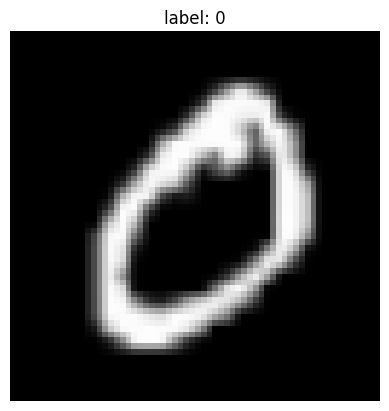

In [8]:
plt.imshow((image.squeeze(0) + 1) / 2, cmap="gray", vmin=0, vmax=1)
plt.title(f"label: {label}")
plt.axis("off")


In [9]:
device = 'cuda'
generator = Generator(100, 10)
discriminator = Discriminator()

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init)

generator.to(device)
discriminator.to(device)


Discriminator(
  (embedding): Embedding(10, 4096)
  (net): Sequential(
    (0): Conv2d(2, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=8192, out_features=1, bias=True)
  )
)

In [10]:
generator_optimizer = torch.optim.Adam(generator.parameters(), lr = 2e-4, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr = 2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

Epoch 1/60 | D Loss: 0.9562 | G Loss: 2.2983
Epoch 2/60 | D Loss: 1.2391 | G Loss: 1.3851
Epoch 3/60 | D Loss: 1.2364 | G Loss: 1.3143
Epoch 4/60 | D Loss: 1.2185 | G Loss: 1.3615
Epoch 5/60 | D Loss: 1.1950 | G Loss: 1.3926


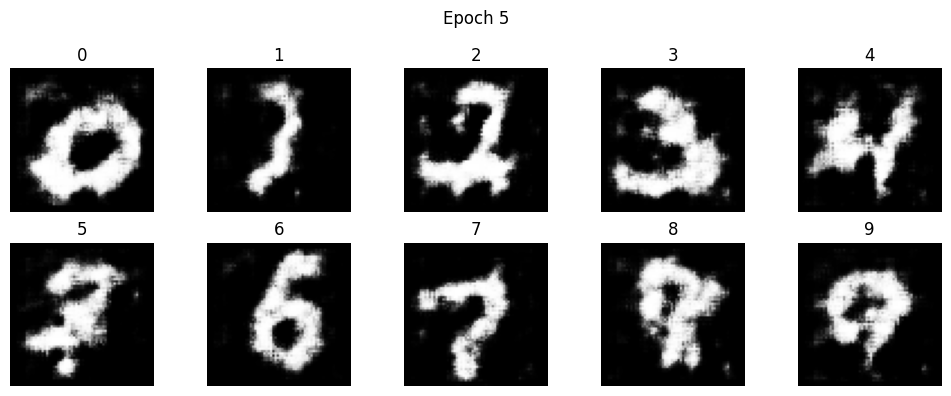

Epoch 6/60 | D Loss: 1.1679 | G Loss: 1.4230
Epoch 7/60 | D Loss: 1.1508 | G Loss: 1.4780
Epoch 8/60 | D Loss: 1.0604 | G Loss: 1.6012
Epoch 9/60 | D Loss: 1.0393 | G Loss: 1.6568
Epoch 10/60 | D Loss: 0.9995 | G Loss: 1.7433


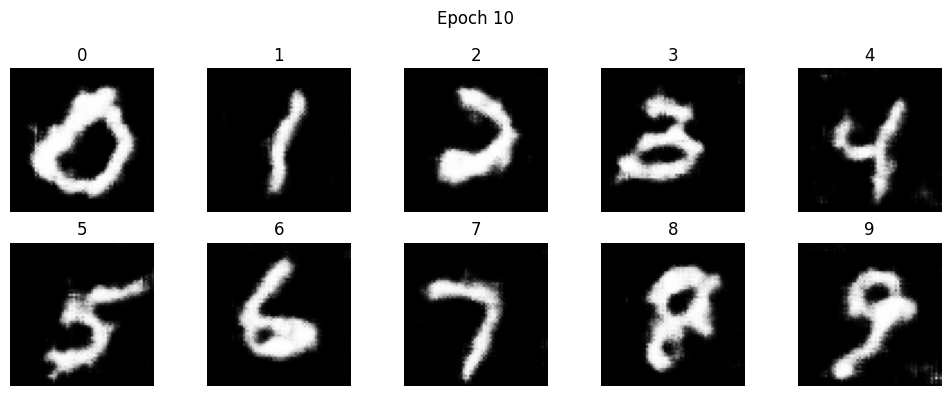

Epoch 11/60 | D Loss: 0.9842 | G Loss: 1.7940
Epoch 12/60 | D Loss: 0.9054 | G Loss: 1.8835
Epoch 13/60 | D Loss: 0.8923 | G Loss: 1.9598
Epoch 14/60 | D Loss: 0.8289 | G Loss: 2.0567
Epoch 15/60 | D Loss: 0.8007 | G Loss: 2.1638


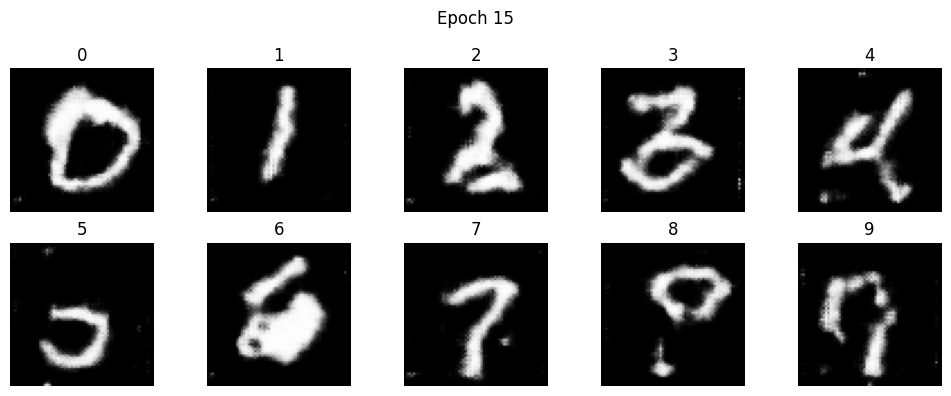

Epoch 16/60 | D Loss: 0.7653 | G Loss: 2.2845
Epoch 17/60 | D Loss: 0.7317 | G Loss: 2.3436
Epoch 18/60 | D Loss: 0.7387 | G Loss: 2.3469
Epoch 19/60 | D Loss: 0.6892 | G Loss: 2.4943
Epoch 20/60 | D Loss: 0.6971 | G Loss: 2.5069


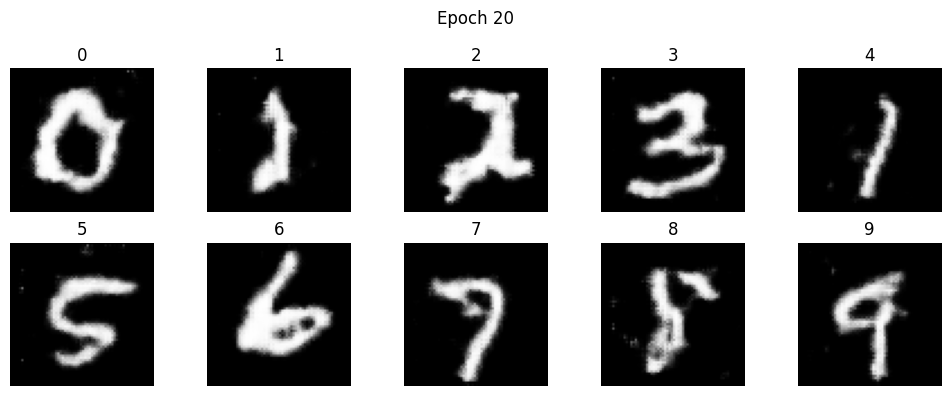

Epoch 21/60 | D Loss: 0.6385 | G Loss: 2.6221
Epoch 22/60 | D Loss: 0.6526 | G Loss: 2.7399
Epoch 23/60 | D Loss: 0.6071 | G Loss: 2.7885
Epoch 24/60 | D Loss: 0.6257 | G Loss: 2.7974
Epoch 25/60 | D Loss: 0.6239 | G Loss: 2.8399


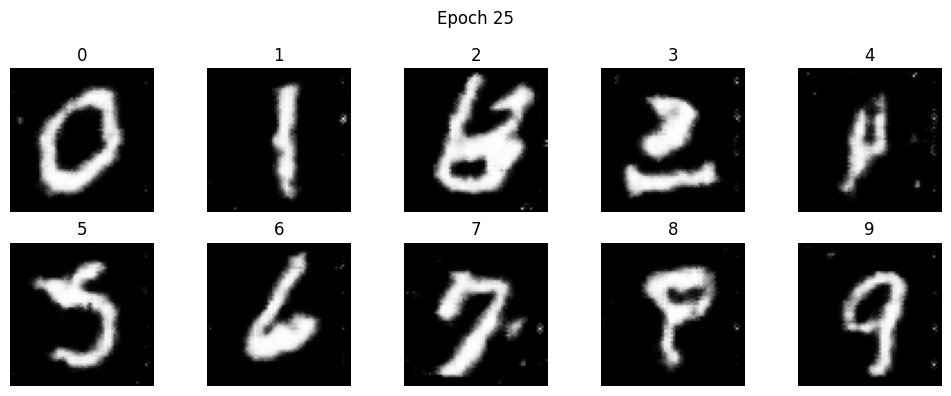

Epoch 26/60 | D Loss: 0.5983 | G Loss: 2.9051
Epoch 27/60 | D Loss: 0.5944 | G Loss: 2.9790
Epoch 28/60 | D Loss: 0.5965 | G Loss: 2.9324
Epoch 29/60 | D Loss: 0.5747 | G Loss: 3.0351
Epoch 30/60 | D Loss: 0.5775 | G Loss: 2.9838


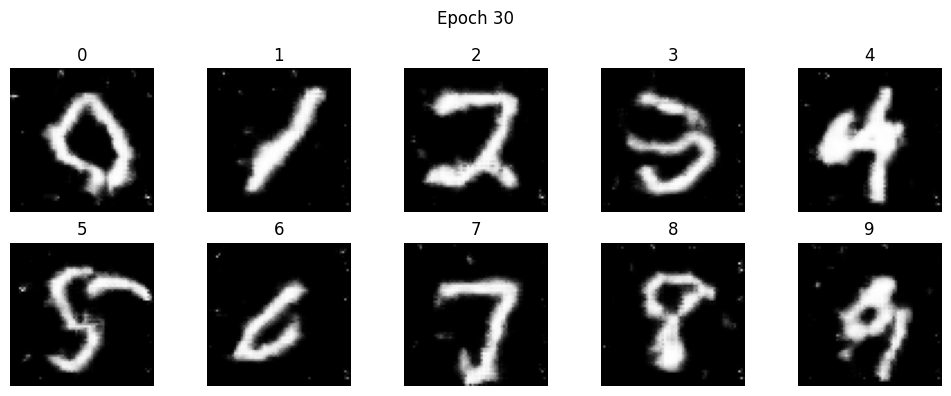

Epoch 31/60 | D Loss: 0.5821 | G Loss: 3.0913
Epoch 32/60 | D Loss: 0.5695 | G Loss: 3.0914
Epoch 33/60 | D Loss: 0.6060 | G Loss: 3.0246
Epoch 34/60 | D Loss: 0.5561 | G Loss: 3.1229
Epoch 35/60 | D Loss: 0.5552 | G Loss: 3.1087


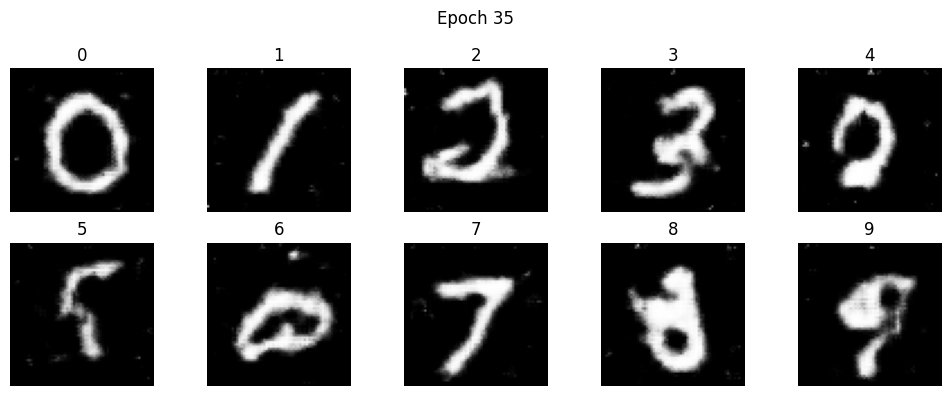

Epoch 36/60 | D Loss: 0.5571 | G Loss: 3.1335
Epoch 37/60 | D Loss: 0.5590 | G Loss: 3.1678
Epoch 38/60 | D Loss: 0.5384 | G Loss: 3.1878
Epoch 39/60 | D Loss: 0.5728 | G Loss: 3.1649
Epoch 40/60 | D Loss: 0.5320 | G Loss: 3.1976


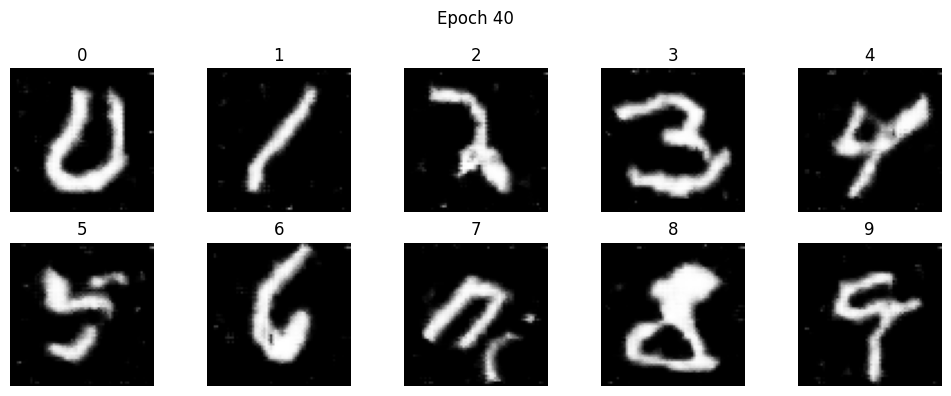

Epoch 41/60 | D Loss: 0.5685 | G Loss: 3.2187
Epoch 42/60 | D Loss: 0.5290 | G Loss: 3.3014
Epoch 43/60 | D Loss: 0.5453 | G Loss: 3.2752
Epoch 44/60 | D Loss: 0.5245 | G Loss: 3.3345
Epoch 45/60 | D Loss: 0.5688 | G Loss: 3.2293


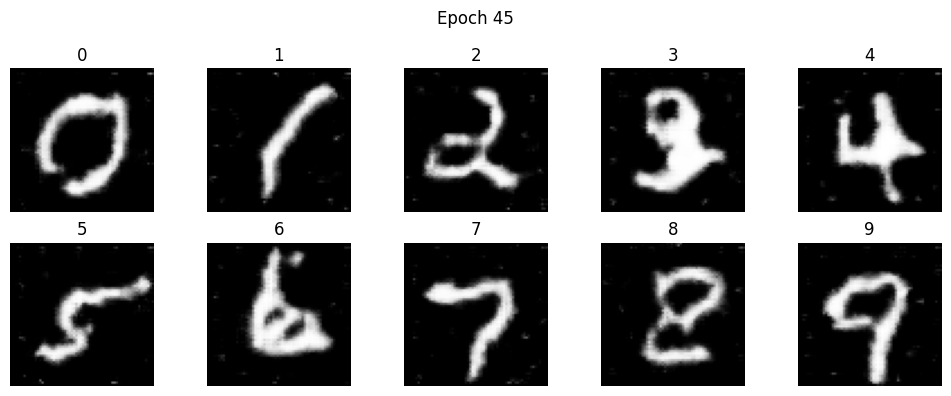

Epoch 46/60 | D Loss: 0.5408 | G Loss: 3.1674
Epoch 47/60 | D Loss: 0.5343 | G Loss: 3.3041
Epoch 48/60 | D Loss: 0.5347 | G Loss: 3.3409


In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch

epochs = 60

fixed_z = torch.randn(10, 100, device=device)
fixed_labels = torch.arange(10, device=device)

for epoch in range(epochs):
    generator.train()
    discriminator.train()

    running_d_loss = 0.0
    running_g_loss = 0.0

    for image, labels in train_loader:
        image = image.to(device)
        labels = labels.to(device)

        batch_size = image.size(0)

        z = torch.randn(batch_size, 100, device=device)
        fake_images = generator(z, labels)

        real_pred = discriminator(image, labels)
        fake_pred = discriminator(fake_images.detach(), labels)

        real_targets = torch.full_like(real_pred, 0.9)
        fake_targets = torch.zeros_like(fake_pred)

        loss_real = criterion(real_pred, real_targets)
        loss_fake = criterion(fake_pred, fake_targets)
        d_loss = loss_real + loss_fake

        discriminator_optimizer.zero_grad()
        d_loss.backward()
        discriminator_optimizer.step()

        fake_pred = discriminator(fake_images, labels)
        g_loss = criterion(fake_pred, torch.ones_like(fake_pred))

        generator_optimizer.zero_grad()
        g_loss.backward()
        generator_optimizer.step()

        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()

    avg_d_loss = running_d_loss / len(train_loader)
    avg_g_loss = running_g_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

    if (epoch + 1) % 5 == 0:
        generator.eval()
        with torch.no_grad():
            samples = generator(fixed_z, fixed_labels).cpu()

        fig, axes = plt.subplots(2, 5, figsize=(10, 4))

        for i, ax in enumerate(axes.flatten()):
            img = samples[i]
            img = (img + 1) / 2
            img = img.clamp(0, 1)

            if img.shape[0] == 1:
                ax.imshow(img.squeeze(0), cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(img.permute(1, 2, 0))

            ax.set_title(str(i))
            ax.axis("off")

        plt.suptitle(f"Epoch {epoch+1}")
        plt.tight_layout()
        plt.show()


In [ ]:
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')